<div style="text-align: center;"> 
    <span style="font-size: 40px; font-weight: bold">
        DATATHON 2026 - THE GRIDBREAKER
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 32px; font-weight: bold">
        FIRST ROUND
    </span>
</div>

<div style="text-align: center;"> 
    <span style="font-size: 24px; font-weight: bold">
        <i>
            Visualize & Analyse <br>
            Q246
        </i>
    </span>
</div>

<div style="text-align: right;">
    <span style="font-size: 14px">
        <i>
            April 22, 2026
        </i>
    </span>
</div>

| Name | Email |
| --- | --- |
| Nguyễn Phạm Tú Uyên | nguyenphamtuuyen0101@gmail.com |

<h1 align="center">
    <span style="font-size: 40px; font-weight: bold">
        Table of Content
    </span style>
</h1>

I. [**Câu 2. Giải mã Trải nghiệm Kém: Từ Chất lượng Sản phẩm đến Vận hành**](#i)

II. [**Câu 4. hám phá Nút thắt Chuỗi Cung ứng & Quản trị Tồn kho**](#ii)

III. [**Câu 6. Bóc tách Động lực Tăng trưởng & Hiệu ứng Mùa vụ**](#iii)

In [1]:
# Import thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data") 

FILES = {
    "products": DATA_DIR / "products.csv",
    "orders": DATA_DIR / "orders.csv",
    "order_items": DATA_DIR / "order_items.csv",
    "shipments": DATA_DIR / "shipments.csv",
    "returns": DATA_DIR / "returns.csv",
    "reviews": DATA_DIR / "reviews.csv",
    "geography": DATA_DIR / "geography.csv",
    "inventory": DATA_DIR / "inventory.csv",
    "promotions": DATA_DIR / "promotions.csv",
}

def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")
    return pd.read_csv(path)

data = {name: load_csv(path) for name, path in FILES.items()}

<h1 id="i" style="font-weight: bold"> Câu 2. Giải mã Trải nghiệm Kém: Từ Chất lượng Sản phẩm đến Vận hành </h1>

- **Câu hỏi:** Tỷ lệ trả hàng (`returns.csv`) và đánh giá thấp (`reviews.csv`) bị chi phối nhiều nhất bởi yếu tố đặc tính sản phẩm hay bởi điểm nghẽn logistics?
  
- **Mục tiêu:** Tìm ra nguyên nhân gốc rễ và đề xuất hành động cụ thể cho bộ phận QA.

**Tải dữ liệu**

In [2]:
products = data['products']
orders = data['orders']
order_items = data['order_items']
shipments = data['shipments']
returns = data['returns']
reviews = data['reviews']
geography = data['geography']

**Tiền xử lý dữ liệu**

In [3]:
# Parse date
orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
shipments["ship_date"] = pd.to_datetime(shipments["ship_date"], errors="coerce")
shipments["delivery_date"] = pd.to_datetime(shipments["delivery_date"], errors="coerce")
returns["return_date"] = pd.to_datetime(returns["return_date"], errors="coerce")
reviews["review_date"] = pd.to_datetime(reviews["review_date"], errors="coerce")

In [4]:
# Kiểm tra trùng key trong returns
dup_returns = returns.duplicated(subset=["order_id", "product_id"]).sum()
print("Số dòng trùng (order_id, product_id) trong returns:", dup_returns)

# Gom returns về 1 dòng / (order_id, product_id)
returns_clean = returns.groupby(["order_id", "product_id"], as_index=False).agg(
    return_id=("return_id", "first"),
    return_date=("return_date", "max"),
    return_reason=("return_reason", "first"),
    return_quantity=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum")
)

Số dòng trùng (order_id, product_id) trong returns: 2


In [5]:
dup_reviews = reviews.duplicated(subset=["order_id", "product_id"]).sum()
print("Số dòng trùng (order_id, product_id) trong reviews:", dup_reviews)

reviews_clean = reviews.groupby(["order_id", "product_id"], as_index=False).agg(
    review_id=("review_id", "first"),
    review_date=("review_date", "max"),
    rating=("rating", "mean")
)

Số dòng trùng (order_id, product_id) trong reviews: 0


**Về phía sản phẩm**

In [6]:
df_product = order_items.merge(
    products[["product_id", "product_name", "category", "segment", "size", "color", "price", "cogs"]],
    on="product_id",
    how="left"
)

df_product = df_product.merge(
    returns_clean[["order_id", "product_id", "return_id", "return_reason", "return_quantity", "refund_amount"]],
    on=["order_id", "product_id"],
    how="left"
)

df_product = df_product.merge(
    reviews_clean[["order_id", "product_id", "review_id", "rating"]],
    on=["order_id", "product_id"],
    how="left"
)

df_product["return_flag"] = np.where(df_product["return_id"].notna(), 1, 0)

df_product["low_rating_flag"] = np.where(
    df_product["rating"].notna() & (df_product["rating"] <= 2),
    1, 0
)

def group_return_reason(x):
    if pd.isna(x) or x == "nan":
        return "no_return"
    elif x == "wrong_size":
        return "size_fit_issue"
    elif x in ["defective", "not_as_described"]:
        return "quality_product_issue"
    elif x == "late_delivery":
        return "logistics_issue"
    elif x == "changed_mind":
        return "customer_preference"
    else:
        return "other_issue"

df_product["return_reason_group"] = df_product["return_reason"].apply(group_return_reason)

In [7]:
# 1) Tỷ lệ trả hàng theo category
product_by_category = (
    df_product.groupby("category")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
    .sort_values("return_rate", ascending=False)
)

# 2) Tỷ lệ trả hàng theo size
product_by_size = (
    df_product.groupby("size")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
    .sort_values("return_rate", ascending=False)
)

# 3) Tỷ lệ trả hàng theo phân khúc
summary_segment = (
    df_product.groupby("segment")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
    .sort_values("return_rate", ascending=False)
)

# 4) Cơ cấu lý do trả hàng
reason_summary = (
    df_product.loc[df_product["return_flag"] == 1, "return_reason_group"]
    .value_counts()
    .reset_index()
)
reason_summary.columns = ["return_reason_group", "count"]

print("Category:")
display(product_by_category)

print("Size:")
display(product_by_size)

print("Segment:")
display(summary_segment)

print("Return reasons:")
display(reason_summary)

Category:


,category,n_items,return_rate,low_rating_rate
1,GenZ,37159,0.057214,0.020587
2,Outdoor,259986,0.056618,0.020813
3,Streetwear,393533,0.055393,0.020763
0,Casual,23991,0.053937,0.021675


Size:


,size,n_items,return_rate,low_rating_rate
2,S,172042,0.056515,0.020344
0,L,173174,0.056250,0.020944
1,M,176428,0.055660,0.020847
3,XL,193025,0.055200,0.021044


Segment:


,segment,n_items,return_rate,low_rating_rate
7,Trendy,37159,0.057214,0.020587
0,Activewear,230375,0.056799,0.020953
4,Performance,96730,0.056260,0.021059
3,Everyday,182533,0.055568,0.020588
5,Premium,31032,0.055491,0.019850
6,Standard,10937,0.054951,0.019841
2,Balanced,103333,0.054320,0.020894
1,All-weather,22570,0.053478,0.021622


Return reasons:


,return_reason_group,count
0,quality_product_issue,15056
1,size_fit_issue,13966
2,customer_preference,6931
3,logistics_issue,3986


Phân tích sơ bộ cho thấy tỷ lệ trả hàng theo danh mục, phân khúc và kích cỡ có khác biệt nhưng không lớn ở mức tổng thể. Điều này gợi ý rằng vấn đề có thể không nằm ở định vị phân khúc mà nằm ở các yếu tố cụ thể hơn bên trong. Tỷ lệ đánh giá thấp giữa các nhóm sản phẩm cũng khá đồng đều, chỉ quanh 2%. Vì vậy, phân tích tiếp theo sẽ đi sâu vào cơ cấu lý do trả hàng và các tổ hợp phân khúc–kích cỡ / danh mục–kích cỡ để tìm ra insight cụ thể hơn.

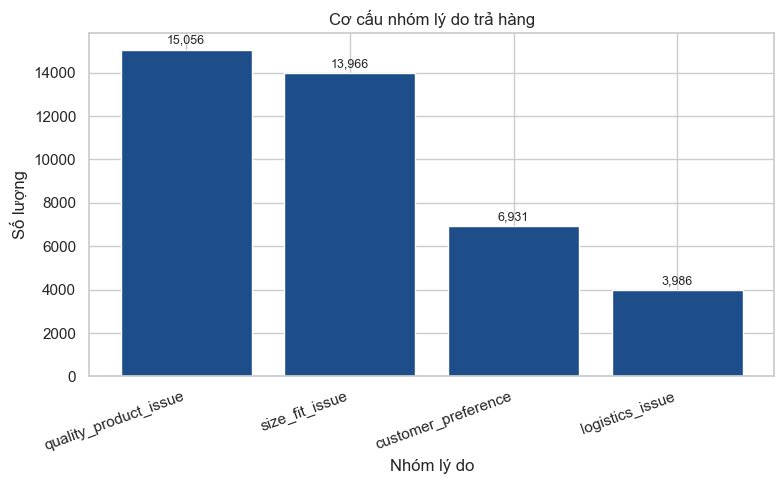

In [8]:
plt.figure(figsize=(8, 5))
bars = plt.bar(reason_summary["return_reason_group"], reason_summary["count"], color="#1d4e89")

plt.xticks(rotation=20, ha="right")
plt.title("Cơ cấu nhóm lý do trả hàng")
plt.xlabel("Nhóm lý do")
plt.ylabel("Số lượng")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(reason_summary["count"]) * 0.01,
        f"{int(h):,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

Hai nguyên nhân lớn nhất của trả hàng là lỗi chất lượng và sai kích cỡ, và đều cao hơn nhiều so với logistics. Điều này cho thấy trả hàng chủ yếu đến từ phía sản phẩm, không phải vận chuyển.

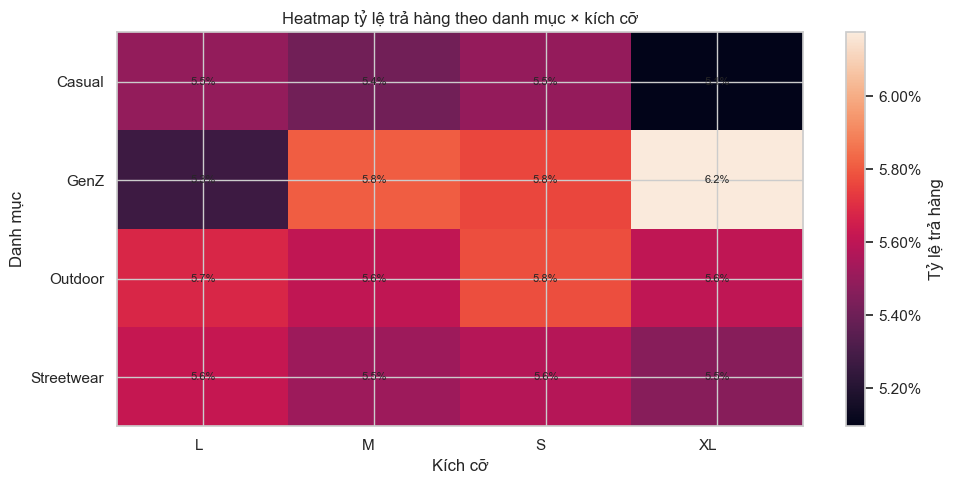

In [9]:
heatmap_data = (
    df_product.groupby(["category", "size"])
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean")
    )
    .reset_index()
)

heatmap_data = heatmap_data[heatmap_data["n_items"] >= 20].copy()

heatmap_pivot = heatmap_data.pivot(
    index="category",
    columns="size",
    values="return_rate"
)

plt.figure(figsize=(10, 5))
im = plt.imshow(heatmap_pivot, aspect="auto")

plt.title("Heatmap tỷ lệ trả hàng theo danh mục × kích cỡ")
plt.xlabel("Kích cỡ")
plt.ylabel("Danh mục")

plt.xticks(
    ticks=range(len(heatmap_pivot.columns)),
    labels=heatmap_pivot.columns,
    ha="right"
)

plt.yticks(
    ticks=range(len(heatmap_pivot.index)),
    labels=heatmap_pivot.index
)

for i in range(heatmap_pivot.shape[0]):
    for j in range(heatmap_pivot.shape[1]):
        val = heatmap_pivot.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
cbar.set_label("Tỷ lệ trả hàng")

plt.tight_layout()
plt.show()

Tỷ lệ trả hàng không khác quá lớn giữa các danh mục, nhưng có một số tổ hợp nổi bật như GenZ – XL cao hơn mặt bằng chung, trong khi Casual – XL thấp hơn rõ. Điều này cho thấy vấn đề tập trung ở một số nhóm sản phẩm–kích cỡ cụ thể, không phải toàn bộ danh mục.

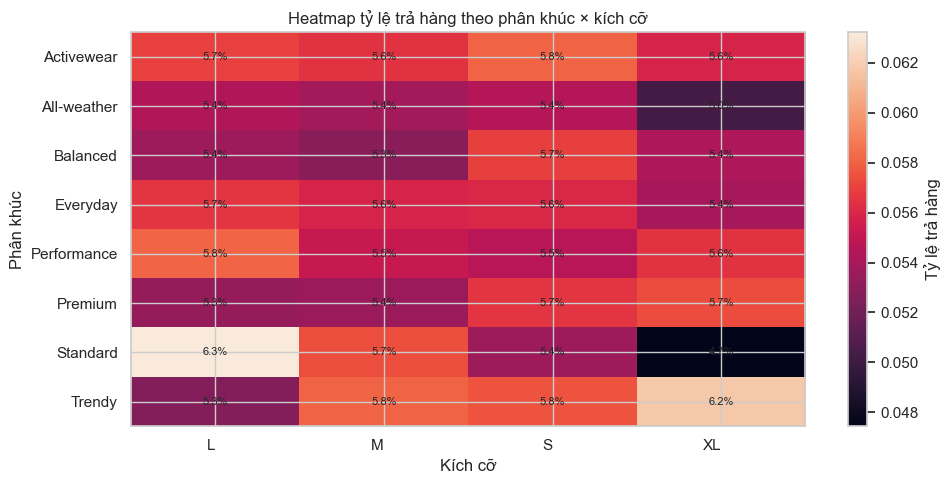

In [10]:
heatmap_seg_size = (
    df_product.groupby(["segment", "size"])
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean")
    )
    .reset_index()
)

heatmap_seg_size = heatmap_seg_size[heatmap_seg_size["n_items"] >= 20].copy()

heatmap_seg_size_pivot = heatmap_seg_size.pivot(
    index="segment",
    columns="size",
    values="return_rate"
)

plt.figure(figsize=(10, 5))
im = plt.imshow(heatmap_seg_size_pivot, aspect="auto")

plt.title("Heatmap tỷ lệ trả hàng theo phân khúc × kích cỡ")
plt.xlabel("Kích cỡ")
plt.ylabel("Phân khúc")

plt.xticks(
    ticks=range(len(heatmap_seg_size_pivot.columns)),
    labels=heatmap_seg_size_pivot.columns,
    ha="right"
)
plt.yticks(
    ticks=range(len(heatmap_seg_size_pivot.index)),
    labels=heatmap_seg_size_pivot.index
)

for i in range(heatmap_seg_size_pivot.shape[0]):
    for j in range(heatmap_seg_size_pivot.shape[1]):
        val = heatmap_seg_size_pivot.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.1%}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im)
cbar.set_label("Tỷ lệ trả hàng")

plt.tight_layout()
plt.show()

Ở cấp phân khúc, chênh lệch hiện rõ hơn, như Standard – L và Trendy – XL có tỷ lệ trả hàng cao, trong khi Standard – XL thấp hơn hẳn. Điều này gợi ý doanh nghiệp nên kiểm tra size chart, form dáng và chất lượng theo từng dòng sản phẩm cụ thể.

Nhận xét: 

- Nhìn chung, phần trả hàng đang bị chi phối chủ yếu bởi đặc tính sản phẩm, đặc biệt là chất lượng và size, thay vì logistics.

- Tỷ lệ đánh giá thấp giữa các nhóm sản phẩm khá đồng đều, chỉ dao động quanh 2%, nên product-side chưa cho thấy khác biệt đủ mạnh ở mức tổng thể. Vì vậy, phần tiếp theo sẽ tập trung kiểm tra liệu low rating có bị chi phối rõ hơn bởi các yếu tố logistics hay không.

Về phía Logistics

In [11]:
df_logistics = order_items.merge(
    orders[["order_id", "order_date", "customer_id", "zip"]],
    on="order_id",
    how="left"
)

df_logistics = df_logistics.merge(
    shipments[["order_id", "ship_date", "delivery_date", "shipping_fee"]],
    on="order_id",
    how="left"
)

df_logistics = df_logistics.merge(
    reviews[["order_id", "product_id", "review_id", "rating"]],
    on=["order_id", "product_id"],
    how="left"
)

df_logistics = df_logistics.merge(
    geography[["zip", "city", "region", "district"]],
    on="zip",
    how="left"
)

df_logistics = df_logistics.merge(
    returns_clean[["order_id", "product_id", "return_id"]],
    on=["order_id", "product_id"],
    how="left"
)

df_logistics["return_flag"] = np.where(df_logistics["return_id"].notna(), 1, 0)

In [12]:
# Thời gian từ đặt hàng đến giao cho bên vận chuyển
df_logistics["prepare_days"] = (df_logistics["ship_date"] - df_logistics["order_date"]).dt.days
df_logistics.loc[df_logistics["prepare_days"] < 0, "prepare_days"] = np.nan

# Số ngày giao hàng
df_logistics["delivery_days"] = (df_logistics["delivery_date"] - df_logistics["ship_date"]).dt.days
df_logistics.loc[df_logistics["delivery_days"] < 0, "delivery_days"] = np.nan

# Tổng thời gian từ đặt đến giao
df_logistics["total_fulfillment_days"] = (df_logistics["delivery_date"] - df_logistics["order_date"]).dt.days
df_logistics.loc[df_logistics["total_fulfillment_days"] < 0, "total_fulfillment_days"] = np.nan

# Cờ đánh giá thấp
df_logistics["low_rating_flag"] = np.where(
    df_logistics["rating"].notna() & (df_logistics["rating"] <= 2),
    1, 0
)

# Bucket thời gian giao hàng
df_logistics["delivery_bucket"] = pd.cut(
    df_logistics["delivery_days"],
    bins=[-1, 2, 5, 8, 999],
    labels=["0-2 ngày", "3-5 ngày", "6-8 ngày", ">8 ngày"]
)

# Bucket phí ship
df_logistics["shipping_fee_bucket"] = pd.qcut(
    df_logistics["shipping_fee"],
    q=3,
    labels=["thấp", "trung bình", "cao"],
    duplicates="drop"
)

In [13]:
# Summary theo thời gian xử lý đơn
summary_prepare = (
    df_logistics.groupby("prepare_days")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
    .sort_values("prepare_days")
)

# Summary theo bucket giao hàng
summary_delivery = (
    df_logistics.groupby("delivery_bucket")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
)

# Summary theo khu vực
summary_region = (
    df_logistics.groupby("region")
    .agg(
        n_items=("order_id", "count"),
        avg_prepare_days=("prepare_days", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
    .sort_values("low_rating_rate", ascending=False)
)

# Summary theo phí ship
summary_shipping_fee = (
    df_logistics.groupby("shipping_fee_bucket")
    .agg(
        n_items=("order_id", "count"),
        return_rate=("return_flag", "mean"),
        low_rating_rate=("low_rating_flag", "mean")
    )
    .reset_index()
)

print("Prepare days:")
display(summary_prepare.head(10))

print("Delivery bucket:")
display(summary_delivery)

print("Region:")
display(summary_region.head(10))

print("Shipping fee bucket:")
display(summary_shipping_fee)

Prepare days:


,prepare_days,n_items,return_rate,low_rating_rate
0,0.0,157005,0.063348,0.023426
1,1.0,156046,0.065051,0.023743
2,2.0,156233,0.064007,0.024457
3,3.0,156098,0.063050,0.023466


Delivery bucket:


,delivery_bucket,n_items,return_rate,low_rating_rate
0,0-2 ngày,104194,0.063497,0.023936
1,3-5 ngày,312852,0.064270,0.023557
2,6-8 ngày,208336,0.063436,0.024014


Region:


,region,n_items,avg_prepare_days,avg_delivery_days,return_rate,low_rating_rate
2,West,192034,1.496512,4.498728,0.056782,0.021616
1,East,321293,1.498986,4.499755,0.055572,0.020586
0,Central,201342,1.497755,4.499346,0.055527,0.020373


Shipping fee bucket:


,shipping_fee_bucket,n_items,return_rate,low_rating_rate
0,thấp,209752,0.064381,0.024305
1,trung bình,208386,0.063354,0.023567
2,cao,207244,0.063852,0.023441


Phân tích sơ bộ cho thấy các biến logistics như thời gian xử lý đơn, thời gian giao hàng, khu vực và phí ship đều chưa tạo ra khác biệt đủ lớn đối với tỷ lệ đánh giá thấp và tỷ lệ trả hàng.

**Kết luận câu 2:**

Ở phía sản phẩm, hai nhóm nguyên nhân lớn nhất ở lý do trả hàng là lỗi chất lượng và sai kích cỡ. Rủi ro trả hàng tập trung ở một số tổ hợp cụ thể, thay vì phân bố đều trên toàn bộ sản phẩm. Cho thấy rằng pain point chính của trả hàng nghiêng rõ về phía đặc tính sản phẩm, đặc biệt là quality và size.

Ở phía logistics, các biến như thời gian xử lý đơn, thời gian giao hàng, khu vực và phí ship đều chưa tạo ra khác biệt đủ lớn đối với tỷ lệ đánh giá thấp. Low rating giữa các nhóm chỉ dao động nhẹ quanh khoảng 2.3%–2.4%, cho thấy logistics chưa phải là tín hiệu nổi bật ở mức tổng thể trong bộ dữ liệu này.

Tổng hợp lại, đặc tính sản phẩm là yếu tố chi phối chính của trải nghiệm kém, đặc biệt thông qua hiện tượng trả hàng. Trong khi đó, phía logistics chưa cho thấy tác động đủ mạnh để trở thành pain point chính. Từ góc độ kinh doanh, doanh nghiệp nên ưu tiên rà soát bảng size, cải thiện mô tả sản phẩm và tăng kiểm soát chất lượng ở các nhóm sản phẩm có tỷ lệ trả hàng cao.

<h1 id="ii" style="font-weight: bold"> Câu 4. Khám phá nút thắt Chuỗi Cung ứng & Quản trị Tồn kho </h1>

- **Câu hỏi:** Dựa trên `inventory.csv`, những danh mục/phân khúc nào thường xuyên đối mặt với tình trạng đứt gãy hàng hóa (`stockout_flag`) hoặc ứ đọng vốn (`overstock_flag`)? Sự chênh lệch giữa tốc độ nhập (`units_received`) và bán (`units_sold`) xảy ra ở giai đoạn nào?

- **Mục tiêu:** Xây dựng quy tắc cảnh báo tái đặt hàng (`reorder_flag`) tự động. Đề xuất xả hàng đối với nhóm overstock và tăng dự báo nhập hàng với nhóm stockout để tối ưu dòng tiền.

**Tải và tiền xử lý dữ liệu**

In [14]:
inventory = data["inventory"]

for col in ["inventory_date", "snapshot_date", "date"]:
    if col in inventory.columns:
        inventory[col] = pd.to_datetime(inventory[col], errors="coerce")

inventory["inventory_gap"] = inventory["units_received"] - inventory["units_sold"]

inventory.head()

,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month,inventory_gap
0,2022-10-31,1,3,1,1,2,90.0,0.9333,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,10,0
1,2022-11-30,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,11,0
2,2022-12-31,1,3,1,1,1,90.0,0.9667,1,0,0,0.2500,DragonWear MA-01,Casual,All-weather,2022,12,0
3,2016-04-30,3,35,13,11,2,95.5,0.9333,1,1,0,0.2391,DragonWear MA-03,Casual,All-weather,2016,4,2
4,2016-05-31,3,36,11,10,1,108.0,0.9667,1,1,0,0.2174,DragonWear MA-03,Casual,All-weather,2016,5,1


In [15]:
summary_category_inv = (
    inventory.groupby("category")
    .agg(
        n_records=("product_id", "count"),
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
        avg_units_sold=("units_sold", "mean"),
        avg_units_received=("units_received", "mean"),
        avg_inventory_gap=("inventory_gap", "mean")
    )
    .reset_index()
    .sort_values("stockout_rate", ascending=False)
)

summary_segment_inv = (
    inventory.groupby("segment")
    .agg(
        n_records=("product_id", "count"),
        stockout_rate=("stockout_flag", "mean"),
        overstock_rate=("overstock_flag", "mean"),
        avg_stockout_days=("stockout_days", "mean"),
        avg_fill_rate=("fill_rate", "mean"),
        avg_sell_through=("sell_through_rate", "mean"),
        avg_units_sold=("units_sold", "mean"),
        avg_units_received=("units_received", "mean"),
        avg_inventory_gap=("inventory_gap", "mean")
    )
    .reset_index()
    .sort_values("stockout_rate", ascending=False)
)

print("Theo category:")
display(summary_category_inv)

print("Theo segment:")
display(summary_segment_inv)

Theo category:


,category,n_records,stockout_rate,overstock_rate,avg_stockout_days,avg_fill_rate,avg_sell_through,avg_units_sold,avg_units_received,avg_inventory_gap
1,GenZ,4674,0.682927,0.716303,1.148481,0.961718,0.167978,10.418271,12.047711,1.629439
2,Outdoor,21050,0.673492,0.798527,1.118860,0.962705,0.135084,16.033729,18.791829,2.758100
3,Streetwear,31020,0.673211,0.749259,1.192553,0.960248,0.159754,16.488298,19.329433,2.841135
0,Casual,3503,0.662004,0.725949,1.145304,0.961823,0.168390,8.907222,10.216386,1.309164


Theo segment:


,segment,n_records,stockout_rate,overstock_rate,avg_stockout_days,avg_fill_rate,avg_sell_through,avg_units_sold,avg_units_received,avg_inventory_gap
7,Trendy,4674,0.682927,0.716303,1.148481,0.961718,0.167978,10.418271,12.047711,1.629439
2,Balanced,6622,0.678949,0.723950,1.257475,0.958084,0.174967,20.404561,23.995017,3.590456
5,Premium,3182,0.678818,0.789441,1.153048,0.961565,0.138364,12.845380,14.972659,2.127278
4,Performance,7673,0.672749,0.746774,1.163430,0.961219,0.156052,16.371563,19.231591,2.860029
0,Activewear,18290,0.672553,0.793002,1.119956,0.962668,0.137252,16.318207,19.133024,2.814817
3,Everyday,13598,0.672378,0.780482,1.207457,0.959751,0.148479,17.391896,20.398882,3.006986
6,Standard,3127,0.665814,0.673169,1.061720,0.964610,0.185655,4.551967,5.038695,0.486728
1,All-weather,3081,0.660500,0.758195,1.107108,0.963096,0.156698,9.535216,10.960727,1.425511


Phân tích sơ bộ cho thấy cả stockout_rate và overstock_rate đều ở mức cao ở hầu hết các danh mục và phân khúc, cho thấy bài toán tồn kho không chỉ là thiếu hàng mà còn là mất cân đối cung–cầu. Ở cấp phân khúc, các nhóm như Balanced, Everyday, Activewear và Premium có overstock_rate cao đồng thời inventory_gap dương khá lớn, nghĩa là lượng nhập đang vượt lượng bán. Ngược lại, Standard là nhóm tương đối ổn định hơn với inventory_gap thấp, fill_rate cao và sell_through_rate tốt hơn. Vì vậy, bước tiếp theo nên tập trung trực quan hóa trực tiếp stockout_rate, overstock_rate và inventory_gap theo phân khúc để xác định nhóm cần ưu tiên tái đặt hàng hoặc xả tồn.

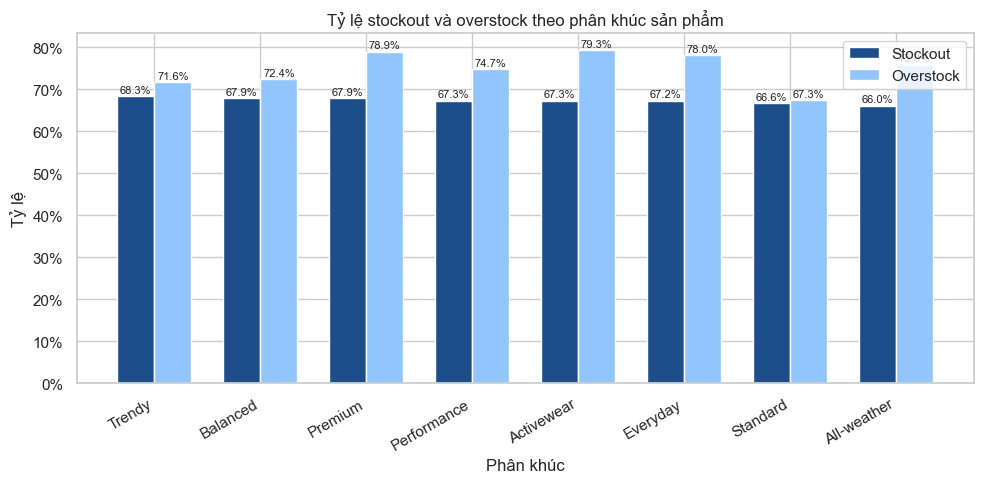

In [16]:
plot_segment_inv = summary_segment_inv.copy()

x = np.arange(len(plot_segment_inv))
width = 0.35

plt.figure(figsize=(10, 5))
bars1 = plt.bar(
    x - width/2,
    plot_segment_inv["stockout_rate"],
    width,
    label="Stockout",
    color="#1d4e89"
)

bars2 = plt.bar(
    x + width/2,
    plot_segment_inv["overstock_rate"],
    width,
    label="Overstock",
    color="#93c5fd"
)

plt.xticks(x, plot_segment_inv["segment"], rotation=30, ha="right")
plt.title("Tỷ lệ stockout và overstock theo phân khúc sản phẩm")
plt.xlabel("Phân khúc")
plt.ylabel("Tỷ lệ")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 0.003,
            f"{h:.1%}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

Biểu đồ cho thấy hầu hết các phân khúc đều có cả stockout và overstock ở mức cao, trong đó overstock thường cao hơn stockout. Các nhóm như Activewear, Premium và Everyday nổi bật với tỷ lệ overstock rất cao, cho thấy doanh nghiệp đang có xu hướng nhập vượt nhu cầu ở nhiều phân khúc.

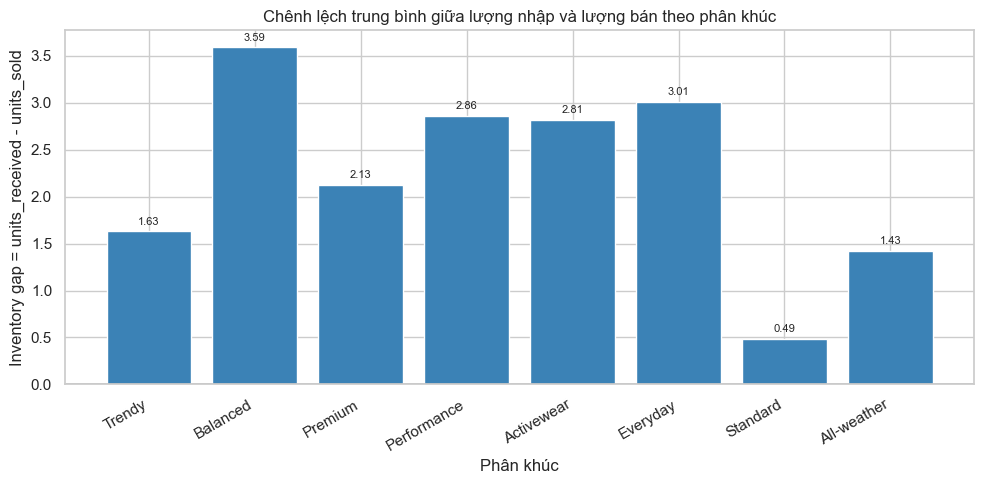

In [17]:
plot_gap = summary_segment_inv.copy()

plt.figure(figsize=(10, 5))
bars = plt.bar(plot_gap["segment"], plot_gap["avg_inventory_gap"], color="#3b82b6")

plt.axhline(0, color="black", linewidth=1)
plt.title("Chênh lệch trung bình giữa lượng nhập và lượng bán theo phân khúc")
plt.xlabel("Phân khúc")
plt.ylabel("Inventory gap = units_received - units_sold")
plt.xticks(rotation=30, ha="right")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.05,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

Biểu đồ inventory_gap cho thấy các phân khúc như Balanced, Everyday, Performance và Activewear có mức chênh lệch dương lớn, tức là lượng nhập đang vượt lượng bán khá rõ. Ngược lại, Standard là nhóm ổn định hơn với mức chênh lệch thấp nhất, cho thấy việc phân bổ tồn kho ở nhóm này đang hợp lý hơn.

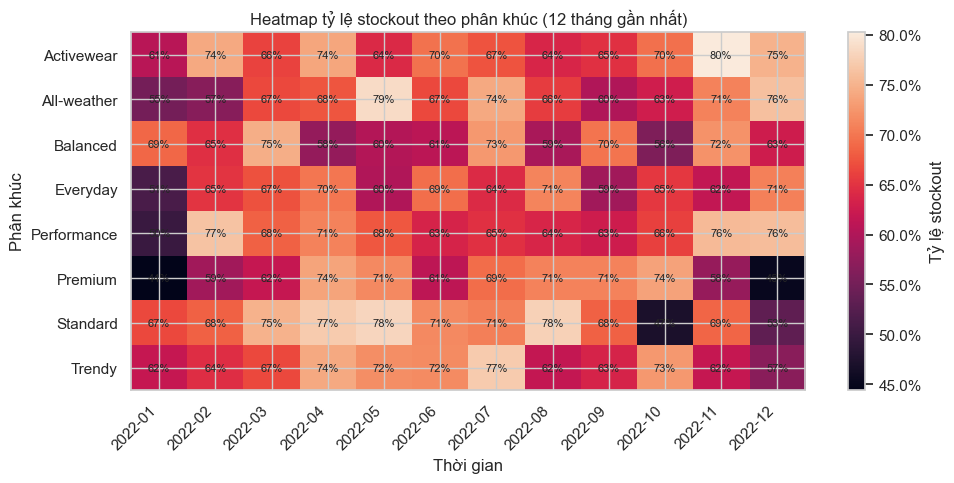

In [18]:
inventory["year_month"] = (
    inventory["year"].astype(str) + "-" +
    inventory["month"].astype(str).str.zfill(2)
)

last_12_months = sorted(inventory["year_month"].dropna().unique())[-12:]

heat_stockout_12m = (
    inventory[inventory["year_month"].isin(last_12_months)]
    .groupby(["segment", "year_month"])
    .agg(stockout_rate=("stockout_flag", "mean"))
    .reset_index()
)

heat_stockout_12m_pivot = heat_stockout_12m.pivot(
    index="segment",
    columns="year_month",
    values="stockout_rate"
)

plt.figure(figsize=(10, 5))
im = plt.imshow(heat_stockout_12m_pivot, aspect="auto")

plt.title("Heatmap tỷ lệ stockout theo phân khúc (12 tháng gần nhất)")
plt.xlabel("Thời gian")
plt.ylabel("Phân khúc")

plt.xticks(
    ticks=range(len(heat_stockout_12m_pivot.columns)),
    labels=heat_stockout_12m_pivot.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    ticks=range(len(heat_stockout_12m_pivot.index)),
    labels=heat_stockout_12m_pivot.index
)

for i in range(heat_stockout_12m_pivot.shape[0]):
    for j in range(heat_stockout_12m_pivot.shape[1]):
        val = heat_stockout_12m_pivot.iloc[i, j]
        if pd.notna(val):
            plt.text(j, i, f"{val:.0%}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im)
cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
cbar.set_label("Tỷ lệ stockout")

plt.tight_layout()
plt.show()

Heatmap cho thấy tỷ lệ stockout biến động theo thời gian và không diễn ra đồng đều giữa các phân khúc. Một số nhóm có những giai đoạn tăng mạnh, chẳng hạn Activewear, Standard và Performance trong một số tháng cuối năm. Điều này cho thấy bài toán tồn kho không chỉ nằm ở tổng lượng nhập mà còn nằm ở việc không điều chỉnh tồn kho theo từng giai đoạn.

**Kết luận câu 4:**

Dữ liệu cho thấy bài toán tồn kho hiện tại là mất cân đối cung–cầu, chứ không chỉ đơn thuần là thiếu hàng. Nhiều phân khúc đồng thời có stockout_rate và overstock_rate cao, trong khi inventory_gap dương cho thấy lượng nhập đang vượt lượng bán ở nhiều nhóm. Điều này gợi ý rằng vấn đề không nằm ở tổng lượng nhập chung, mà ở việc phân bổ tồn kho chưa khớp theo từng phân khúc và theo thời điểm. Tuy nhiên, do dữ liệu inventory hiện tại chưa đi sâu đến cấp size/SKU, phân tích mới chỉ có thể kết luận ở cấp phân khúc. Vì vậy, doanh nghiệp nên ưu tiên rà soát lại forecast nhập hàng theo từng phân khúc và bổ sung yếu tố thời gian / mùa vụ vào chính sách reorder, thay vì dùng một ngưỡng tái đặt hàng cố định cho toàn bộ sản phẩm.

<h1 id="iii" style="font-weight: bold"> Câu 6. Bóc tách Động lực Tăng trưởng & Hiệu ứng Mùa vụ </h1>

- **Câu hỏi:** Biến động doanh thu theo thời gian thực chất đến từ việc mở rộng tệp khách/tăng số lượng đơn hàng, hay do tăng giá trị trung bình trên mỗi đơn? Các đỉnh doanh thu trong năm là kết quả của nhu cầu tự nhiên (mùa vụ) hay là sự đánh đổi lợi nhuận từ các đợt Flash Sale/Khuyến mãi lớn?

- **Mục tiêu:** Bóc tách "tăng trưởng thực" và "tăng trưởng ảo" (do đốt tiền khuyến mãi).

**Tải và tiền xử lý dữ liệu**

In [19]:
promotions = data["promotions"]

In [20]:
order_items["revenue"] = (
    order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"]
)

order_revenue = (
    order_items.groupby("order_id")
    .agg(
        order_revenue=("revenue", "sum"),
        total_units=("quantity", "sum"),
        total_discount=("discount_amount", "sum")
    )
    .reset_index()
)

df_revenue = orders.merge(order_revenue, on="order_id", how="left")

df_revenue["order_date"] = pd.to_datetime(df_revenue["order_date"], errors="coerce")
df_revenue["year"] = df_revenue["order_date"].dt.year
df_revenue["month"] = df_revenue["order_date"].dt.month
df_revenue["year_month"] = df_revenue["order_date"].dt.to_period("M").astype(str)

df_revenue.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,order_revenue,total_units,total_discount,year,month,year_month
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,7967.54,7,0.0,2012,7,2012-07
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,71163.75,7,0.0,2012,7,2012-07
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,33660.99,3,0.0,2012,7,2012-07
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,53196.25,5,0.0,2012,7,2012-07
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1597.84,1,0.0,2012,7,2012-07


In [21]:
promo_1 = order_items[["order_id", "promo_id"]].rename(columns={"promo_id": "promo_id_use"})
promo_2 = order_items[["order_id", "promo_id_2"]].rename(columns={"promo_id_2": "promo_id_use"})

order_promos_long = pd.concat([promo_1, promo_2], ignore_index=True)
order_promos_long = order_promos_long.dropna(subset=["promo_id_use"])
order_promos_long = order_promos_long.drop_duplicates()

promotions["start_date"] = pd.to_datetime(promotions["start_date"], errors="coerce")
promotions["end_date"] = pd.to_datetime(promotions["end_date"], errors="coerce")

order_promos_full = order_promos_long.merge(
    promotions,
    left_on="promo_id_use",
    right_on="promo_id",
    how="left"
)

order_promos_full.head()

,order_id,promo_id_use,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,46253,PROMO-0006,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
1,46254,PROMO-0006,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
2,46257,PROMO-0006,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
3,46258,PROMO-0006,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0
4,46266,PROMO-0006,PROMO-0006,Rural Special 2013,percentage,15.0,2013-01-31,2013-03-01,Outdoor,in_store,0,0


In [22]:
order_promo_summary = (
    order_promos_full.groupby("order_id")
    .agg(
        promo_active_flag=("promo_id_use", lambda x: 1),
        promo_count=("promo_id_use", "nunique"),
        avg_discount_value=("discount_value", "mean"),
        has_stackable=("stackable_flag", "max")
    )
    .reset_index()
)

order_promo_summary.head()

,order_id,promo_active_flag,promo_count,avg_discount_value,has_stackable
0,46253,1,1,15.0,0
1,46254,1,1,15.0,0
2,46257,1,1,15.0,0
3,46258,1,1,15.0,0
4,46266,1,1,15.0,0


In [23]:
df_revenue = df_revenue.merge(
    order_promo_summary,
    on="order_id",
    how="left"
)

df_revenue["promo_active_flag"] = df_revenue["promo_active_flag"].fillna(0)
df_revenue["promo_count"] = df_revenue["promo_count"].fillna(0)
df_revenue["avg_discount_value"] = df_revenue["avg_discount_value"].fillna(0)
df_revenue["has_stackable"] = df_revenue["has_stackable"].fillna(0)

df_revenue.head()

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,order_revenue,total_units,total_discount,year,month,year_month,promo_active_flag,promo_count,avg_discount_value,has_stackable
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,7967.54,7,0.0,2012,7,2012-07,0.0,0.0,0.0,0.0
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,71163.75,7,0.0,2012,7,2012-07,0.0,0.0,0.0,0.0
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,33660.99,3,0.0,2012,7,2012-07,0.0,0.0,0.0,0.0
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,53196.25,5,0.0,2012,7,2012-07,0.0,0.0,0.0,0.0
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1597.84,1,0.0,2012,7,2012-07,0.0,0.0,0.0,0.0


In [24]:
monthly_summary = (
    df_revenue.groupby("year_month")
    .agg(
        total_revenue=("order_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        total_customers=("customer_id", "nunique"),
        total_units=("total_units", "sum"),
        total_discount=("total_discount", "sum"),
        promo_order_share=("promo_active_flag", "mean"),
        avg_promo_count=("promo_count", "mean")
    )
    .reset_index()
)

monthly_summary["aov"] = monthly_summary["total_revenue"] / monthly_summary["total_orders"]
monthly_summary["revenue_per_customer"] = monthly_summary["total_revenue"] / monthly_summary["total_customers"]
monthly_summary["discount_ratio"] = monthly_summary["total_discount"] / monthly_summary["total_revenue"]

monthly_summary["revenue_growth"] = monthly_summary["total_revenue"].pct_change()
monthly_summary["orders_growth"] = monthly_summary["total_orders"].pct_change()
monthly_summary["aov_growth"] = monthly_summary["aov"].pct_change()

monthly_summary_display = monthly_summary[[
    "year_month",
    "total_revenue",
    "total_orders",
    "total_customers",
    "aov",
    "discount_ratio",
    "promo_order_share",
    "revenue_growth",
    "orders_growth",
    "aov_growth"
]]

display(monthly_summary_display.head(12))
display(monthly_summary_display.tail(12))

,year_month,total_revenue,total_orders,total_customers,aov,discount_ratio,promo_order_share,revenue_growth,orders_growth,aov_growth
0,2012-07,1.304068e+08,5294,4883,24632.937951,0.000000,0.000000,NaN,NaN,NaN
1,2012-08,1.590892e+08,6427,5812,24753.265958,0.000000,0.000000,0.219946,0.214016,0.004885
2,2012-09,1.293071e+08,5219,4793,24776.227979,0.000000,0.000000,-0.187204,-0.187957,0.000928
3,2012-10,1.101857e+08,4285,3884,25714.281085,0.000000,0.000000,-0.147876,-0.178961,0.037861
4,2012-11,9.818630e+07,4142,3724,23705.044722,0.000000,0.000000,-0.108902,-0.033372,-0.078137
5,2012-12,1.143226e+08,6684,5810,17103.921408,0.000000,0.000000,0.164344,0.613713,-0.278469
6,2013-01,9.128545e+07,3665,3331,24907.353312,0.000254,0.004638,-0.201510,-0.451676,0.456236
7,2013-02,1.063607e+08,4661,4212,22819.281120,0.032178,0.451405,0.165144,0.271760,-0.083834
8,2013-03,1.415457e+08,6590,5919,21478.860607,0.072690,0.615781,0.330809,0.413860,-0.058741
9,2013-04,1.896518e+08,8874,7888,21371.626776,0.048906,0.407821,0.339863,0.346586,-0.004993


,year_month,total_revenue,total_orders,total_customers,aov,discount_ratio,promo_order_share,revenue_growth,orders_growth,aov_growth
114,2022-01,5.873135e+07,1719,1627,34165.995282,0.015871,0.105876,0.455555,-0.213632,0.850985
115,2022-02,7.910310e+07,2182,2072,36252.564390,0.000000,0.000000,0.346863,0.269343,0.061072
116,2022-03,1.295917e+08,4231,3965,30629.100102,0.061317,0.529189,0.638264,0.939047,-0.155119
117,2022-04,1.332545e+08,4489,4196,29684.672486,0.060418,0.510804,0.028264,0.060978,-0.030834
118,2022-05,1.390279e+08,4076,3827,34108.902640,0.000000,0.000000,0.043326,-0.092003,0.149041
119,2022-06,1.307567e+08,4068,3838,32142.741905,0.038665,0.244346,-0.059493,-0.001963,-0.057644
120,2022-07,8.784272e+07,3122,2984,28136.681153,0.117244,0.631967,-0.328197,-0.232547,-0.124633
121,2022-08,1.135360e+08,3274,3111,34678.071750,0.000061,0.000611,0.292492,0.048687,0.232486
122,2022-09,7.781686e+07,2643,2540,29442.624499,0.102130,0.926220,-0.314606,-0.192731,-0.150973
123,2022-10,7.513702e+07,2097,2011,35830.719638,0.000764,0.007630,-0.034438,-0.206583,0.216968


Bảng summary cho thấy doanh thu biến động theo thời gian chủ yếu đi cùng với số đơn hàng hơn là AOV. Ở nhiều giai đoạn, doanh thu tăng khi orders_growth tăng mạnh, trong khi aov_growth không biến động cùng mức. Đến năm 2022, AOV vẫn tương đối cao nhưng doanh thu giảm rõ do số đơn hàng giảm, cho thấy AOV không đủ bù cho sự suy giảm về lượng đơn.

Ngoài ra, một số tháng cuối kỳ có discount_ratio và promo_order_share tăng mạnh, nhưng doanh thu không tăng tương ứng. Điều này gợi ý rằng khuyến mãi có tác động đến doanh số, nhưng chưa tạo ra tăng trưởng bền vững. Nhìn chung, tăng trưởng doanh thu trong bộ dữ liệu này vẫn chủ yếu đến từ số đơn hàng, còn các đỉnh doanh thu về cuối kỳ có dấu hiệu phụ thuộc nhiều hơn vào promo.

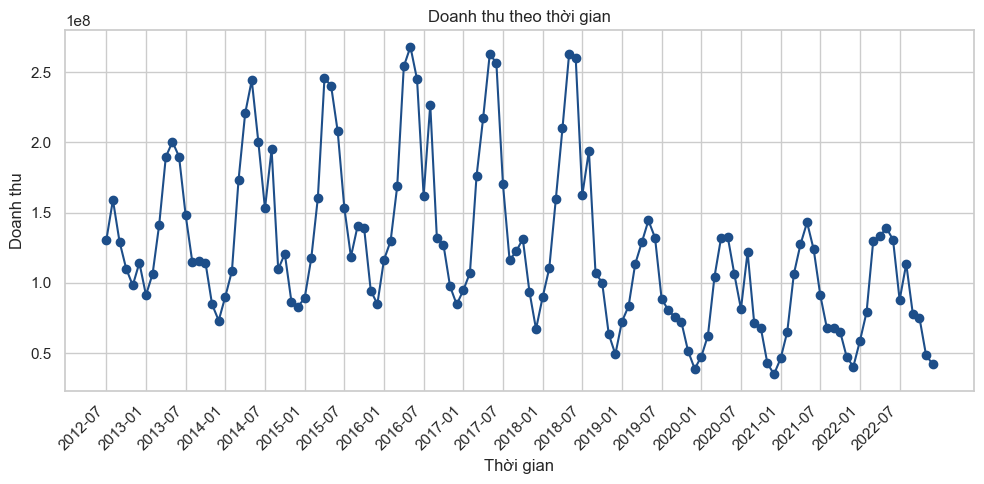

In [25]:
plot_df = monthly_summary.copy()
tick_idx = range(0, len(plot_df), 6)

plt.figure(figsize=(10, 5))
plt.plot(plot_df["year_month"], plot_df["total_revenue"], marker="o", color="#1d4e89")

plt.title("Doanh thu theo thời gian")
plt.xlabel("Thời gian")
plt.ylabel("Doanh thu")
plt.xticks(tick_idx, plot_df["year_month"].iloc[tick_idx], rotation=45, ha="right")
plt.tight_layout()
plt.show()

Biểu đồ cho thấy doanh thu có tính chu kỳ khá rõ, với nhiều đỉnh lặp lại theo thời gian, phản ánh yếu tố mùa vụ trong nhu cầu mua sắm. Tuy nhiên, sau giai đoạn đỉnh khoảng 2016–2018, mặt bằng doanh thu giảm rõ rệt và thấp hơn đáng kể ở các năm cuối, cho thấy tăng trưởng không được duy trì ổn định trong dài hạn.

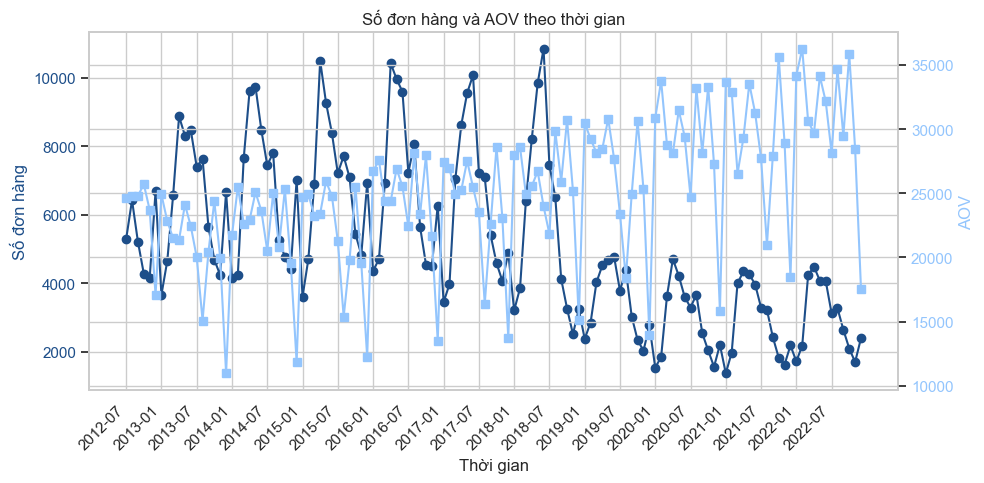

In [26]:
plot_df = monthly_summary.copy()
tick_idx = range(0, len(plot_df), 6)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(plot_df["year_month"], plot_df["total_orders"], marker="o", color="#1d4e89")
ax1.set_xlabel("Thời gian")
ax1.set_ylabel("Số đơn hàng", color="#1d4e89")
ax1.tick_params(axis="y", labelcolor="#1d4e89")
ax1.set_xticks(list(tick_idx))
ax1.set_xticklabels(plot_df["year_month"].iloc[list(tick_idx)], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(plot_df["year_month"], plot_df["aov"], marker="s", color="#93c5fd")
ax2.set_ylabel("AOV", color="#93c5fd")
ax2.tick_params(axis="y", labelcolor="#93c5fd")

plt.title("Số đơn hàng và AOV theo thời gian")
plt.tight_layout()
plt.show()

Biểu đồ cho thấy doanh thu biến động chủ yếu đi cùng với số đơn hàng hơn là AOV. Ở giai đoạn sau, AOV có xu hướng tăng nhưng số đơn hàng lại giảm mạnh, đặc biệt từ khoảng 2019 trở đi. Điều này cho thấy việc tăng giá trị trung bình mỗi đơn không đủ bù cho sự suy giảm của lượng đơn, nên động lực doanh thu chính vẫn là số đơn hàng.

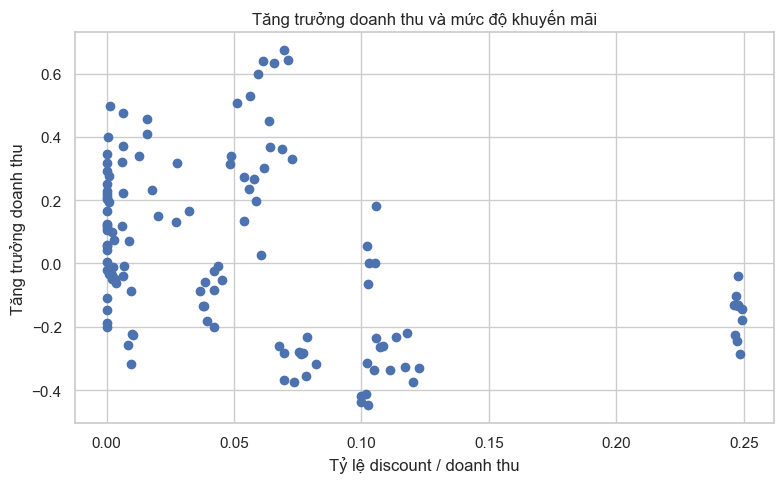

In [27]:
plt.figure(figsize=(8, 5))
plt.scatter(monthly_summary["discount_ratio"], monthly_summary["revenue_growth"])

plt.title("Tăng trưởng doanh thu và mức độ khuyến mãi")
plt.xlabel("Tỷ lệ discount / doanh thu")
plt.ylabel("Tăng trưởng doanh thu")

plt.tight_layout()
plt.show()

Biểu đồ phân tán cho thấy không có mối quan hệ dương rõ rệt giữa mức độ khuyến mãi và tăng trưởng doanh thu. Ngược lại, nhiều tháng có tỷ lệ discount rất cao lại rơi vào vùng tăng trưởng thấp hoặc âm. Điều này cho thấy khuyến mãi có thể hỗ trợ doanh số ngắn hạn, nhưng chưa đủ để tạo ra tăng trưởng bền vững.

**Kết luận câu 6:**

Nhìn chung, biến động doanh thu theo thời gian chủ yếu đến từ số lượng đơn hàng, chứ không phải từ AOV. Các đỉnh doanh thu có tính chu kỳ khá rõ, cho thấy doanh thu chịu ảnh hưởng của mùa vụ; tuy nhiên ở giai đoạn cuối, doanh nghiệp phải sử dụng khuyến mãi với cường độ cao hơn nhưng vẫn không tạo ra mức tăng doanh thu tương xứng. Điều này cho thấy tăng trưởng bền vững vẫn phụ thuộc chủ yếu vào cầu thực và số đơn hàng, trong khi promo chỉ giúp hỗ trợ ngắn hạn chứ không thay thế được nhu cầu tự nhiên.